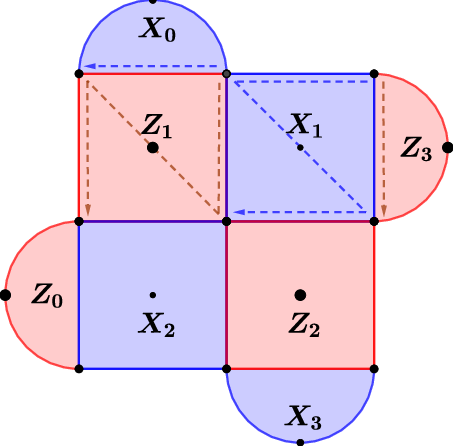

# (A) 디바이스 설정

In [3]:
import pennylane as qml
import numpy as np

n_data = 9
n_anc = 8
n_qubits = n_data + n_anc

dev = qml.device("default.clifford", wires=n_qubits)

ImportError: This feature requires stim, a fast stabilizer circuit simulator. It can be installed with:

pip install stim

# (B) qubit 인덱싱

In [2]:
data_qubits = list(range(9))
anc_x = list(range(9, 13))   # X stabilizer
anc_z = list(range(13, 17))  # Z stabilizer

# (C) stabilizer 연결 정의

In [3]:
# 각 stabilizer가 어떤 data qubit에 연결되는지
Z_stabilizers = [
    [0,1,3,4],
    [1,2,4,5],
    [3,4,6,7],
    [4,5,7,8]
]

X_stabilizers = [
    [0,1,3,4],
    [1,2,4,5],
    [3,4,6,7],
    [4,5,7,8]
]

# (D) Noise 모델 (실재성 핵심)

In [4]:
def apply_noise(p):
    for q in data_qubits:
        qml.DepolarizingChannel(p, wires=q)

# (E) Syndrome 측정 회로

In [5]:
def measure_Z_stabilizer(anc, qubits):
    for q in qubits:
        qml.CNOT(wires=[q, anc])

In [6]:
def measure_X_stabilizer(anc, qubits):
    qml.Hadamard(wires=anc)
    for q in qubits:
        qml.CNOT(wires=[anc, q])
    qml.Hadamard(wires=anc)

# Main

In [10]:
@qml.qnode(dev)
def surface_code_cycle(p=0.01):

    # for q in data_qubits:
    #     qml.BasisState(np.array([0]), wires=q)
    return qml.sample(wires=range(n_qubits))  # 초기화 확인용

    apply_noise(p)

    # stabilizer circuit만 수행
    for i, stab in enumerate(Z_stabilizers):
        measure_Z_stabilizer(anc_z[i], stab)

    for i, stab in enumerate(X_stabilizers):
        measure_X_stabilizer(anc_x[i], stab)

    # 🔥 여기 핵심
    return qml.state()
output = surface_code_cycle(p=0.01)
print(output)

: 

In [ ]:
@qml.qnode(dev)
def surface_code_cycle(p=0.01):

    for q in data_qubits:
        qml.BasisState(np.array([0]), wires=q)

    apply_noise(p)

    # stabilizer circuit만 수행
    for i, stab in enumerate(Z_stabilizers):
        measure_Z_stabilizer(anc_z[i], stab)

    for i, stab in enumerate(X_stabilizers):
        measure_X_stabilizer(anc_x[i], stab)

    # 🔥 여기 핵심
    return qml.sample(wires=anc_z + anc_x)

(<Figure size 4200x1800 with 1 Axes>, <Axes: >)

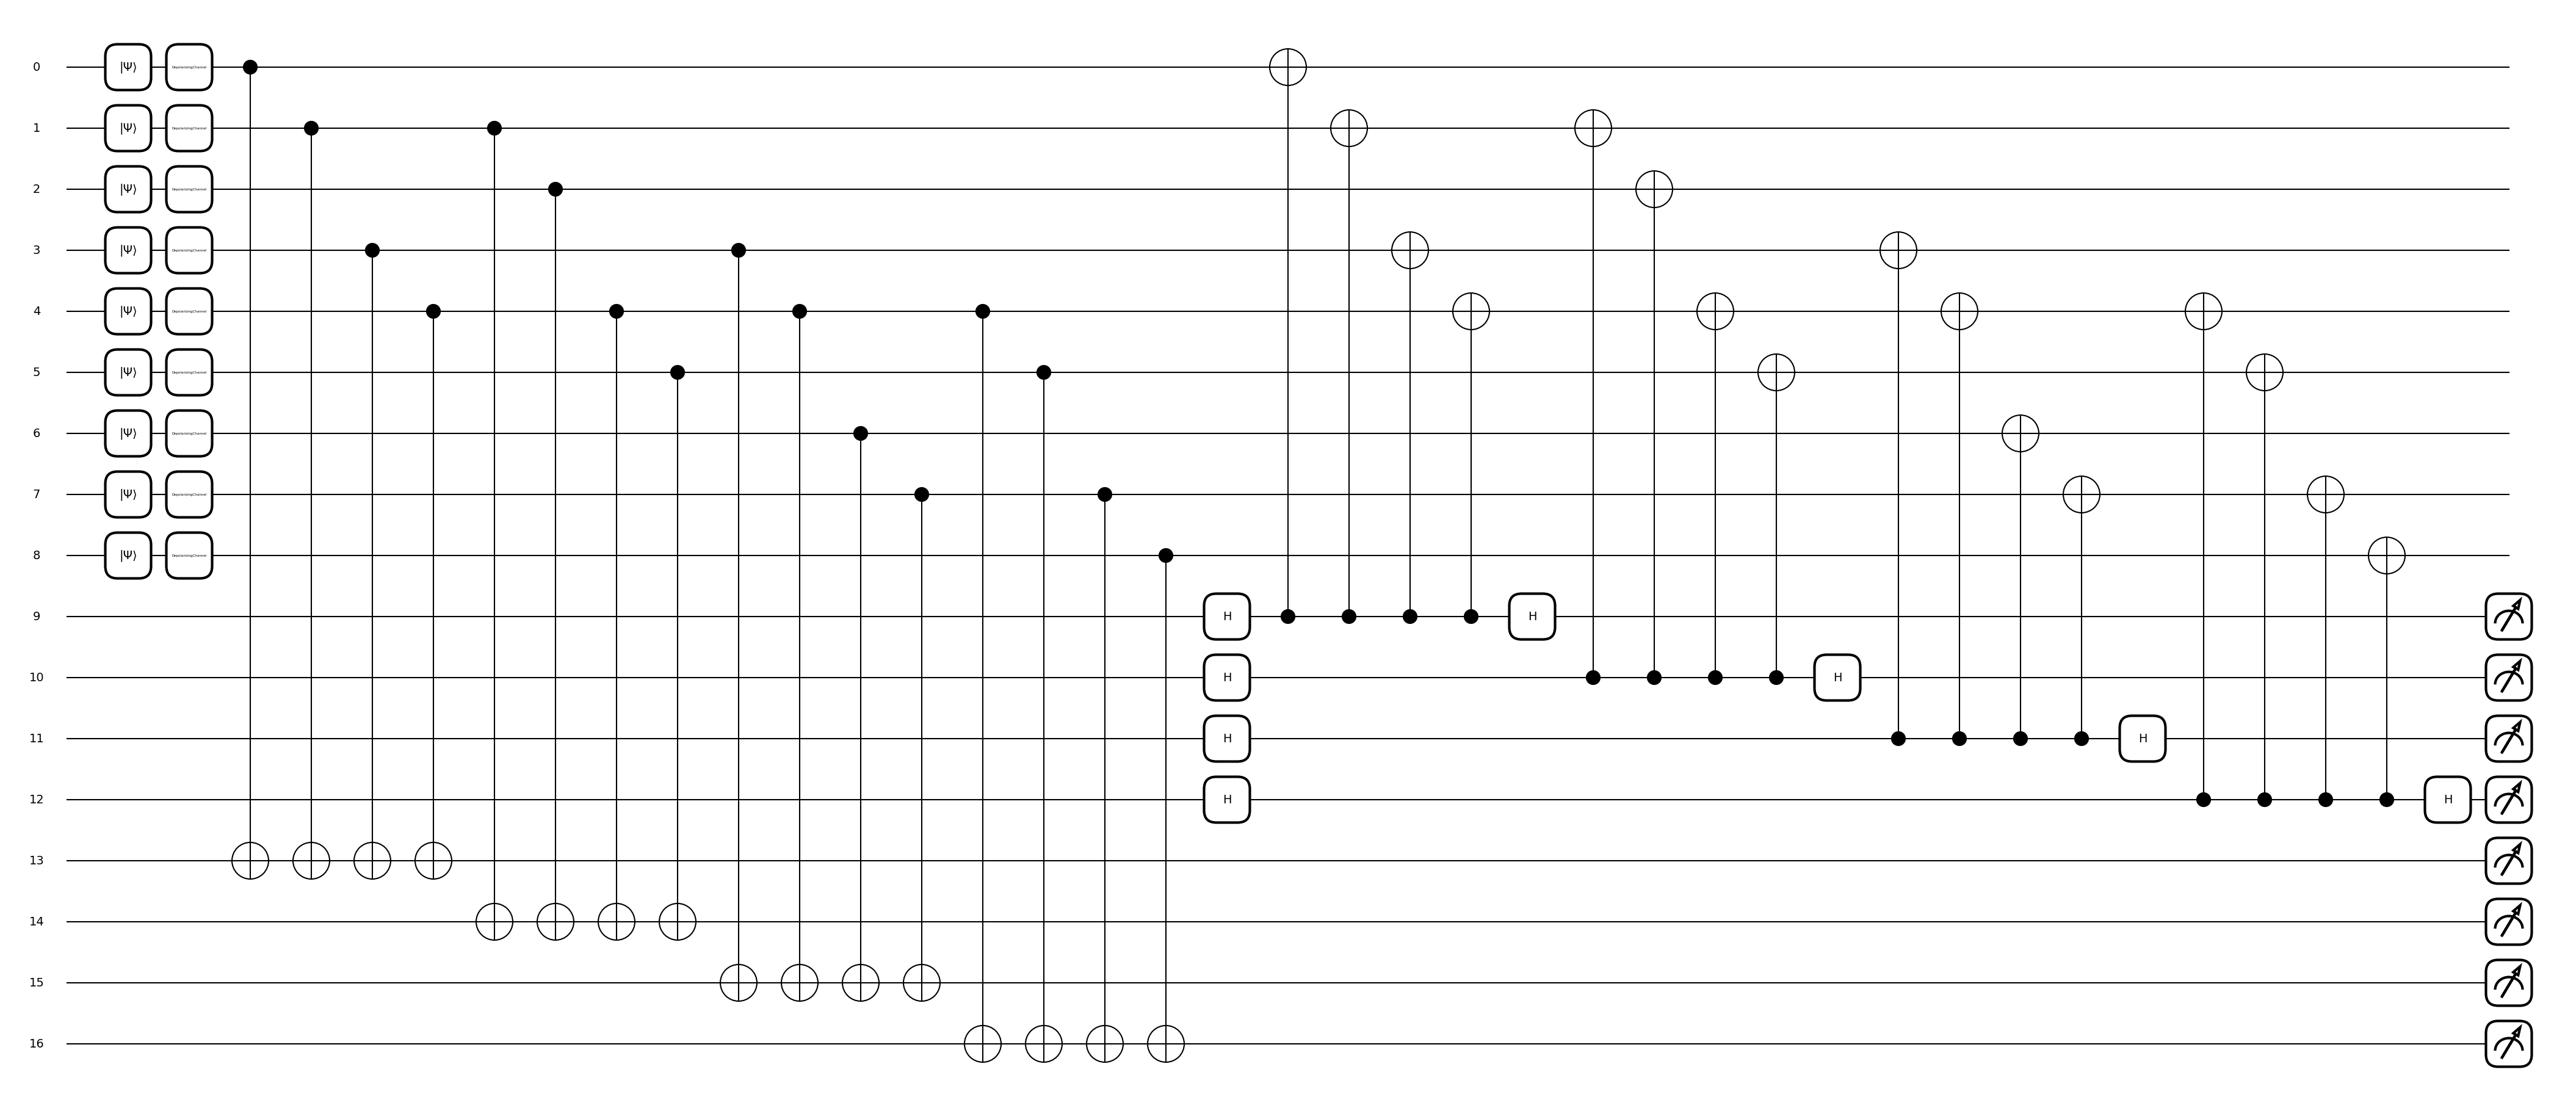

In [8]:
qml.draw_mpl(surface_code_cycle)(p=0.01)

In [9]:
print(surface_code_cycle(0.02))

: 

In [ ]:
for _ in range(5):
    print(surface_code_cycle(0.02))

: 

: 